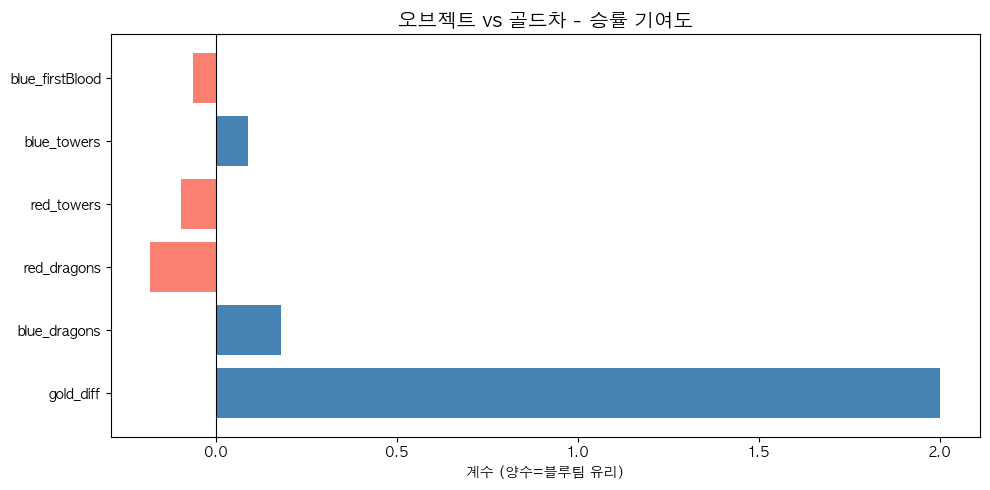

             피처        계수      절댓값
      gold_diff  2.002706 2.002706
   blue_dragons  0.181469 0.181469
    red_dragons -0.180480 0.180480
     red_towers -0.094833 0.094833
    blue_towers  0.090293 0.090293
blue_firstBlood -0.061378 0.061378


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('lol_clean_final.csv')

# 전체 골드차 직접 계산
df['blue_totalGold'] = df['blue_top_gold'] + df['blue_jungle_gold'] + df['blue_middle_gold'] + df['blue_bottom_gold'] + df['blue_utility_gold']
df['red_totalGold']  = df['red_top_gold']  + df['red_jungle_gold']  + df['red_middle_gold']  + df['red_bottom_gold']  + df['red_utility_gold']
df['gold_diff'] = df['blue_totalGold'] - df['red_totalGold']

obj_features  = ['blue_dragons', 'blue_towers', 'blue_firstBlood',
                 'red_dragons',  'red_towers']
gold_features = ['gold_diff']
all_features  = obj_features + gold_features

X = df[all_features].dropna()
y = df.loc[X.index, 'win']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_scaled, y)

coef_df = pd.DataFrame({
    '피처': all_features,
    '계수': lr.coef_[0],
    '절댓값': np.abs(lr.coef_[0])
}).sort_values('절댓값', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['계수']]
ax.barh(coef_df['피처'], coef_df['계수'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('오브젝트 vs 골드차 - 승률 기여도', fontsize=14)
ax.set_xlabel('계수 (양수=블루팀 유리)')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

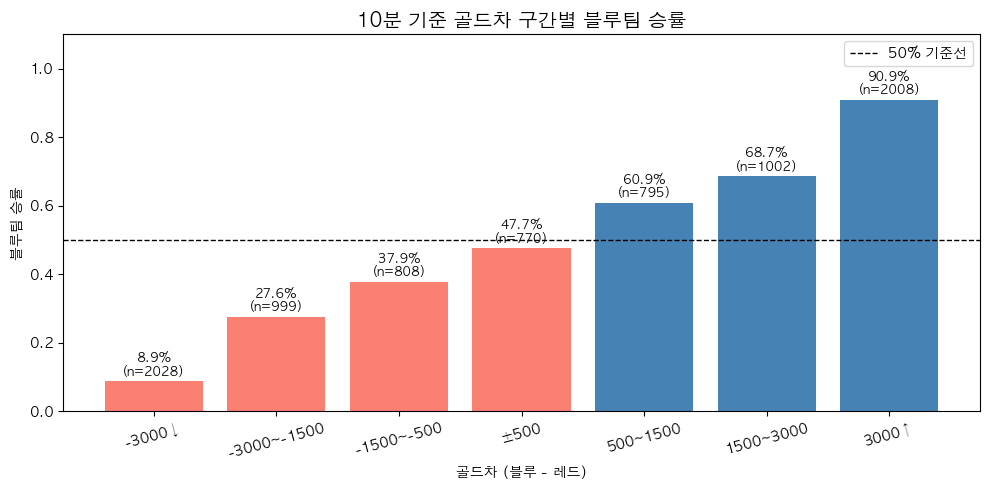

     골드차 구간       승률  게임수
     -3000↓ 0.088757 2028
-3000~-1500 0.276276  999
 -1500~-500 0.378713  808
       ±500 0.476623  770
   500~1500 0.608805  795
  1500~3000 0.686627 1002
      3000↑ 0.909363 2008


In [6]:
bins   = [-np.inf, -3000, -1500, -500, 500, 1500, 3000, np.inf]
labels = ['-3000↓', '-3000~-1500', '-1500~-500', '±500',
          '500~1500', '1500~3000', '3000↑']

df['gold_diff_bin'] = pd.cut(df['gold_diff'], bins=bins, labels=labels)

win_rate = df.groupby('gold_diff_bin', observed=True)['win'].agg(['mean','count']).reset_index()
win_rate.columns = ['골드차 구간', '승률', '게임수']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(win_rate['골드차 구간'], win_rate['승률'],
              color=['salmon' if w < 0.5 else 'steelblue' for w in win_rate['승률']])
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='50% 기준선')

for bar, rate, cnt in zip(bars, win_rate['승률'], win_rate['게임수']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{rate:.1%}\n(n={cnt})', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 1.1)
ax.set_title('10분 기준 골드차 구간별 블루팀 승률', fontsize=14)
ax.set_xlabel('골드차 (블루 - 레드)')
ax.set_ylabel('블루팀 승률')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(win_rate.to_string(index=False))

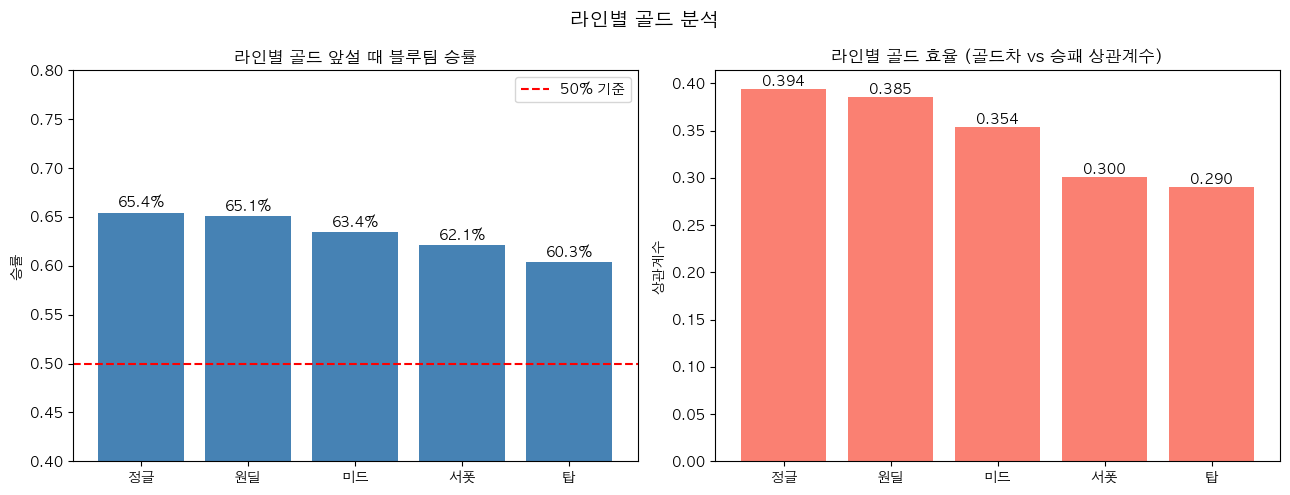

라인  블루 앞설 때 승률  골드차-승패 상관계수  평균 골드차
정글      0.6543       0.3940    37.5
원딜      0.6509       0.3854    -1.8
미드      0.6345       0.3539   -15.2
서폿      0.6208       0.3005   -12.6
 탑      0.6034       0.2902     0.5


In [7]:
lane_pairs = {
    '탑':  'top_gold_diff',
    '정글': 'jungle_gold_diff',
    '미드': 'middle_gold_diff',
    '원딜': 'bottom_gold_diff',
    '서폿': 'utility_gold_diff',
}

results = []
for lane, diff_col in lane_pairs.items():
    ahead     = df[df[diff_col] > 0]
    win_ahead = ahead['win'].mean()
    corr      = df[[diff_col, 'win']].corr().iloc[0, 1]
    avg_diff  = df[diff_col].mean()

    results.append({
        '라인': lane,
        '블루 앞설 때 승률': round(win_ahead, 4),
        '골드차-승패 상관계수': round(corr, 4),
        '평균 골드차': round(avg_diff, 1)
    })

res_df = pd.DataFrame(results).sort_values('골드차-승패 상관계수', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(res_df['라인'], res_df['블루 앞설 때 승률'], color='steelblue')
axes[0].axhline(0.5, color='red', linestyle='--', label='50% 기준')
axes[0].set_title('라인별 골드 앞설 때 블루팀 승률')
axes[0].set_ylabel('승률')
axes[0].set_ylim(0.4, 0.8)
axes[0].legend()
for i, (v, lane) in enumerate(zip(res_df['블루 앞설 때 승률'], res_df['라인'])):
    axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=10)

axes[1].bar(res_df['라인'], res_df['골드차-승패 상관계수'], color='salmon')
axes[1].set_title('라인별 골드 효율 (골드차 vs 승패 상관계수)')
axes[1].set_ylabel('상관계수')
for i, (v, lane) in enumerate(zip(res_df['골드차-승패 상관계수'], res_df['라인'])):
    axes[1].text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('라인별 골드 분석', fontsize=14)
plt.tight_layout()
plt.show()

print(res_df.to_string(index=False))

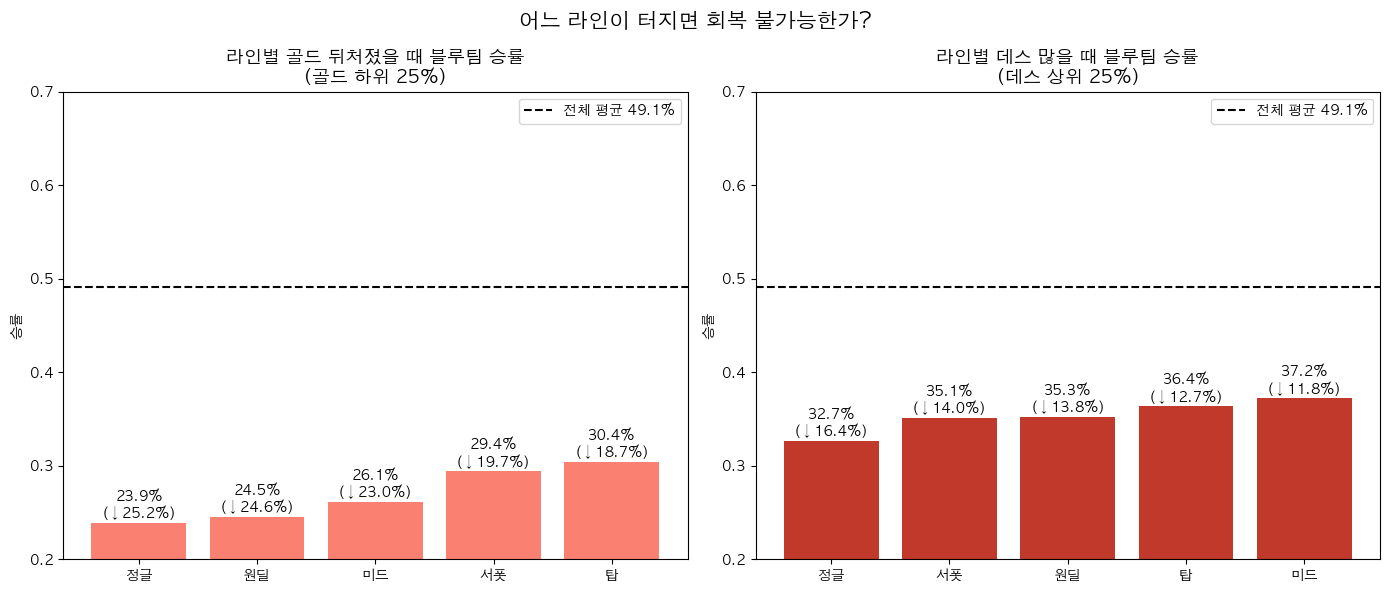

=== 골드 뒤처졌을 때 ===
라인  골드 하위25% 승률  승률 하락폭  게임수
정글       0.2388  0.2519 2106
원딜       0.2452  0.2455 2104
미드       0.2611  0.2297 2103
서폿       0.2939  0.1969 2103
 탑       0.3039  0.1869 2103

=== 데스 많을 때 ===
라인  데스 상위25% 승률  승률 하락폭  게임수
정글       0.3267  0.1641 3193
서폿       0.3512  0.1396 2899
원딜       0.3526  0.1381 2856
 탑       0.3637  0.1270 2466
미드       0.3722  0.1185 3721


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('lol_clean_final.csv')

lanes = {
    '탑':  {'gold': 'top_gold_diff',    'blue_deaths': 'blue_top_deaths'},
    '정글': {'gold': 'jungle_gold_diff', 'blue_deaths': 'blue_jungle_deaths'},
    '미드': {'gold': 'middle_gold_diff', 'blue_deaths': 'blue_middle_deaths'},
    '원딜': {'gold': 'bottom_gold_diff', 'blue_deaths': 'blue_bottom_deaths'},
    '서폿': {'gold': 'utility_gold_diff','blue_deaths': 'blue_utility_deaths'},
}

gold_results   = []
death_results  = []

for lane, cols in lanes.items():
    # 골드 하위 25% (많이 뒤처진 상황)
    q25 = df[cols['gold']].quantile(0.25)
    behind = df[df[cols['gold']] <= q25]
    wr_behind = behind['win'].mean()

    # 전체 평균 승률
    wr_all = df['win'].mean()

    gold_results.append({
        '라인': lane,
        '골드 하위25% 승률': round(wr_behind, 4),
        '승률 하락폭': round(wr_all - wr_behind, 4),
        '게임수': len(behind)
    })

    # 데스 상위 25% (많이 죽은 상황)
    q75_d = df[cols['blue_deaths']].quantile(0.75)
    many_deaths = df[df[cols['blue_deaths']] >= q75_d]
    wr_deaths = many_deaths['win'].mean()

    death_results.append({
        '라인': lane,
        '데스 상위25% 승률': round(wr_deaths, 4),
        '승률 하락폭': round(wr_all - wr_deaths, 4),
        '게임수': len(many_deaths)
    })

gold_df  = pd.DataFrame(gold_results).sort_values('승률 하락폭', ascending=False)
death_df = pd.DataFrame(death_results).sort_values('승률 하락폭', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 골드 하위 25% 승률
bars1 = axes[0].bar(gold_df['라인'], gold_df['골드 하위25% 승률'], color='salmon')
axes[0].axhline(wr_all, color='black', linestyle='--', label=f'전체 평균 {wr_all:.1%}')
axes[0].set_title('라인별 골드 뒤처졌을 때 블루팀 승률\n(골드 하위 25%)', fontsize=13)
axes[0].set_ylabel('승률')
axes[0].set_ylim(0.2, 0.7)
axes[0].legend()
for bar, row in zip(bars1, gold_df.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{row._2:.1%}\n(↓{row._3:.1%})',
                 ha='center', fontsize=10)

# 데스 상위 25% 승률
bars2 = axes[1].bar(death_df['라인'], death_df['데스 상위25% 승률'], color='#c0392b')
axes[1].axhline(wr_all, color='black', linestyle='--', label=f'전체 평균 {wr_all:.1%}')
axes[1].set_title('라인별 데스 많을 때 블루팀 승률\n(데스 상위 25%)', fontsize=13)
axes[1].set_ylabel('승률')
axes[1].set_ylim(0.2, 0.7)
axes[1].legend()
for bar, row in zip(bars2, death_df.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{row._2:.1%}\n(↓{row._3:.1%})',
                 ha='center', fontsize=10)

plt.suptitle('어느 라인이 터지면 회복 불가능한가?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== 골드 뒤처졌을 때 ===")
print(gold_df.to_string(index=False))
print("\n=== 데스 많을 때 ===")
print(death_df.to_string(index=False))